In [1]:
from google.colab import files

uploaded = files.upload()

Saving road(1).jpg to road(1).jpg


In [2]:
import os

print(os.listdir())

['.config', 'road(1).jpg', 'sample_data']


In [3]:
import os

print("Current folder:", os.getcwd())
print("\nFiles:")
for file in os.listdir():
    print(repr(file))

Current folder: /content

Files:
'.config'
'road(1).jpg'
'sample_data'


In [5]:
import cv2
image = cv2.imread('image.jpg')

Height = 735
Width = 1100


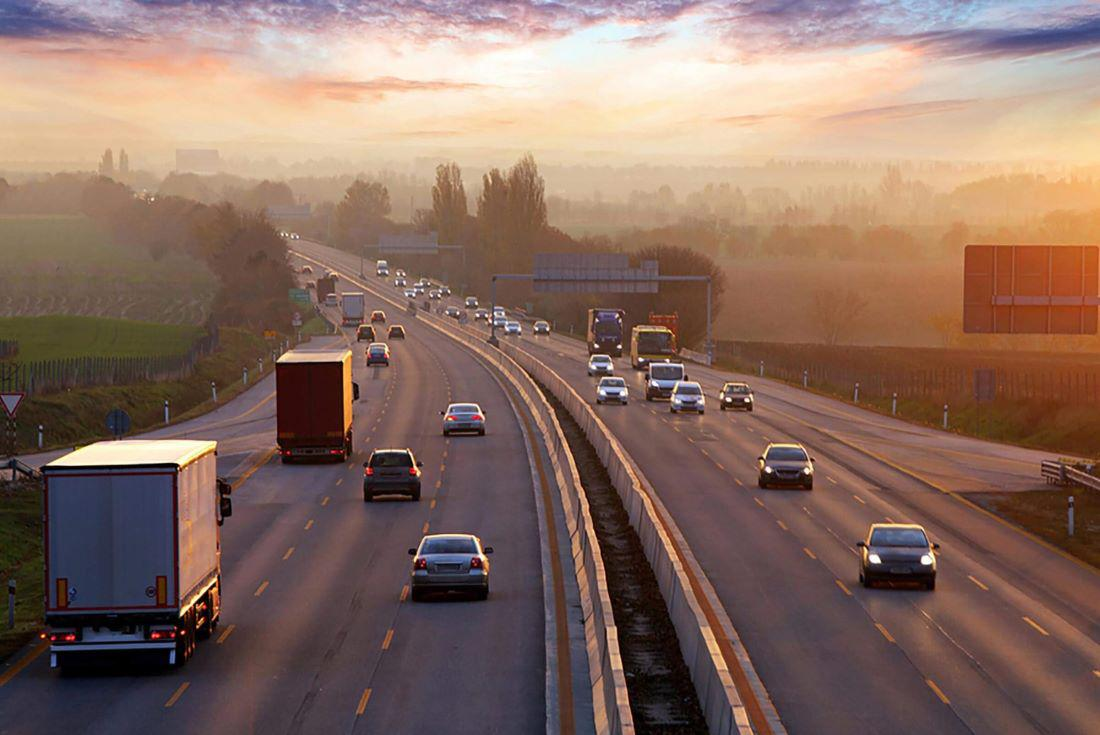

In [7]:
import cv2
from google.colab.patches import cv2_imshow

image = cv2.imread('road(1).jpg')

if image is None:
    print("Could not load the image.")
else:
    h, w = image.shape[:2]
    print("Height =", h)
    print("Width =", w)
    cv2_imshow(image)

Extracting the RGB Values of a Pixel
Now we will focus on extracting the RGB values of an individual pixel. OpenCV arranges the channels in BGR order. So the 0th value will correspond to the Blue pixel and not the Red.

In [8]:
if 'image' not in locals() or image is None:
    # Attempt to reload the image if it's None or not defined.
    # Using 'road(1).jpg' as it's the one known to exist and be loaded successfully elsewhere.
    import cv2
    image = cv2.imread('road(1).jpg')
    if image is None:
        print("Error: Could not load 'road(1).jpg'. Please ensure the file exists and is accessible.")
    else:
        print("Note: 'image' was None or not defined, reloaded 'road(1).jpg'.")

if image is not None:
    (B, G, R) = image[100, 100]
    print("R = {}, G = {}, B = {}".format(R, G, B))

    B = image[100, 100, 0]
    print("B = {}".format(B))

R = 239, G = 200, B = 157
B = 157


Extracting the Region of Interest (ROI)
Sometimes we want to extract a particular part or region of an image. This can be done by slicing the pixels of the image.

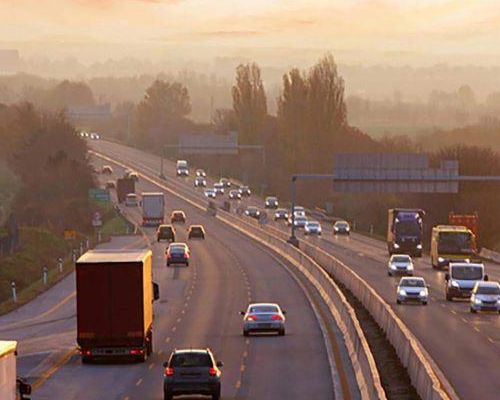

In [9]:
roi = image[100 : 500, 200 : 700]
from google.colab.patches import cv2_imshow
cv2_imshow(roi)

Resizing the Image
We can also resize an image in Python using resize() function of the cv2 module and pass the input image and resize pixel value.

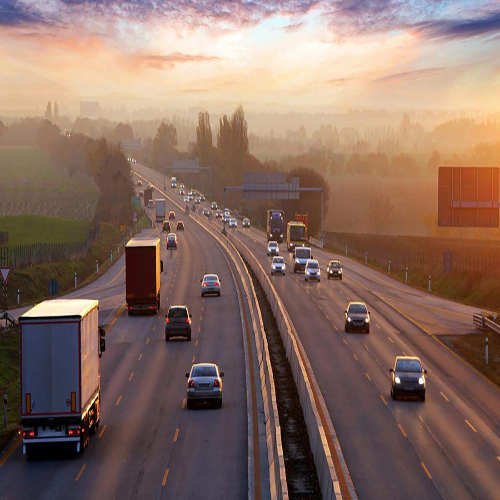

In [10]:
from google.colab.patches import cv2_imshow
resize = cv2.resize(image, (500, 500))
cv2_imshow(resize)

Rotating the Image
The problem with this approach is that the aspect ratio of the image is not maintained. So we need to do some extra work in order to maintain a proper aspect ratio.

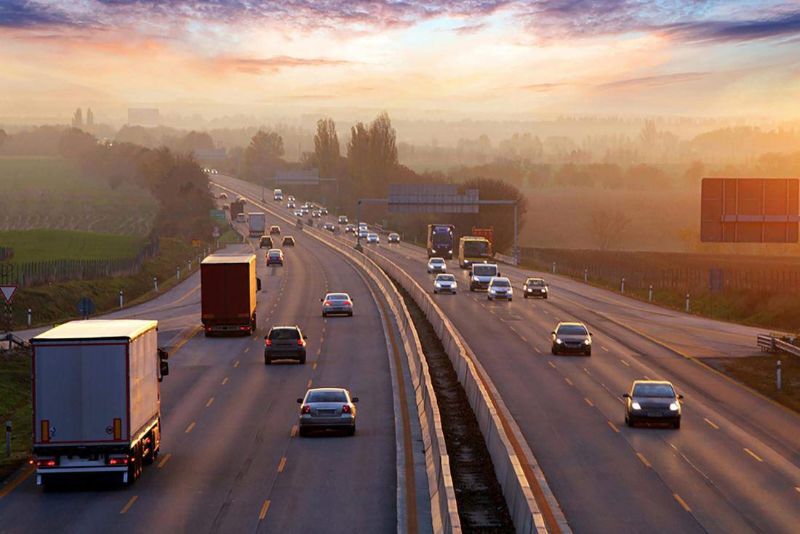

In [11]:
from google.colab.patches import cv2_imshow
ratio = 800 / w
dim = (800, int(h * ratio))

resize_aspect = cv2.resize(image, dim)
cv2_imshow(resize_aspect)

Drawing a Rectangle
We can draw a rectangle on the image using rectangle() method. It takes in 5 arguments:

Image
Top-left corner co-ordinates
Bottom-right corner co-ordinates
Color (in BGR format)
Line width

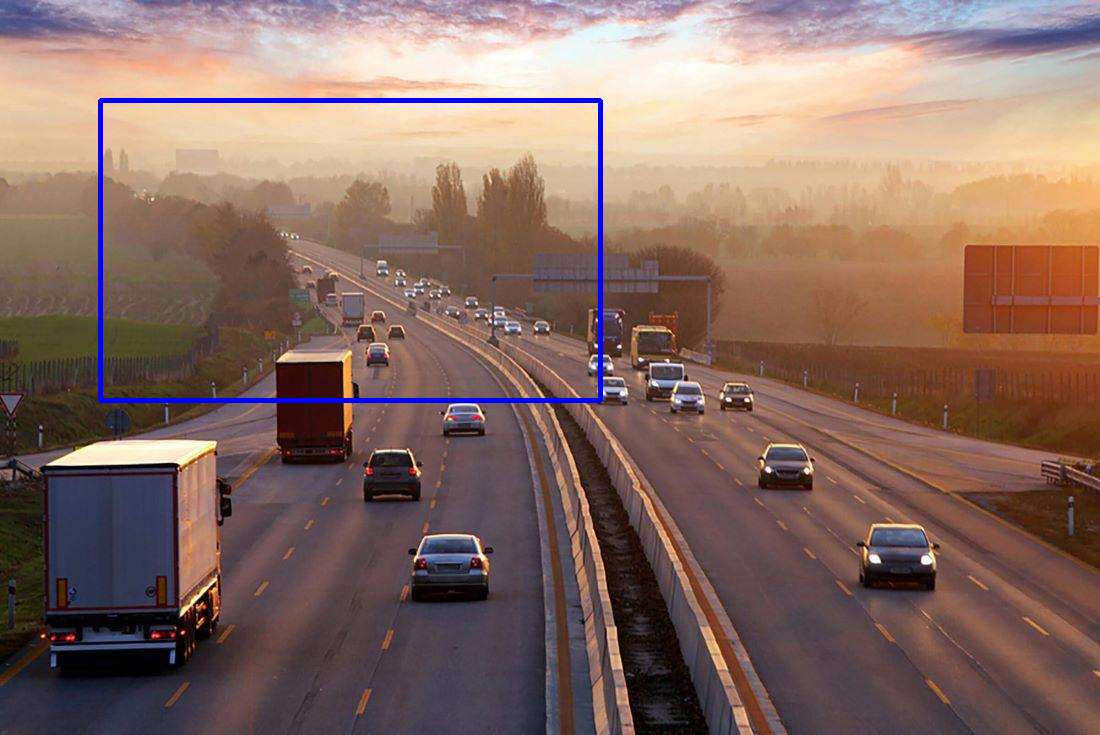

In [12]:


output = image.copy()

cv2.rectangle(
    output,
    (100, 100),
    (600, 400),
    (255, 0, 0),
    3
)

cv2_imshow(output)

Displaying text
It is also an in-place operation that can be done using the putText() method of OpenCV module. It takes in 7 arguments:

Image
Text to be displayed
Bottom-left corner co-ordinates, from where the text should start
Font
Font size
Color (BGR format)
Line width

Image shape: (735, 1100, 3)


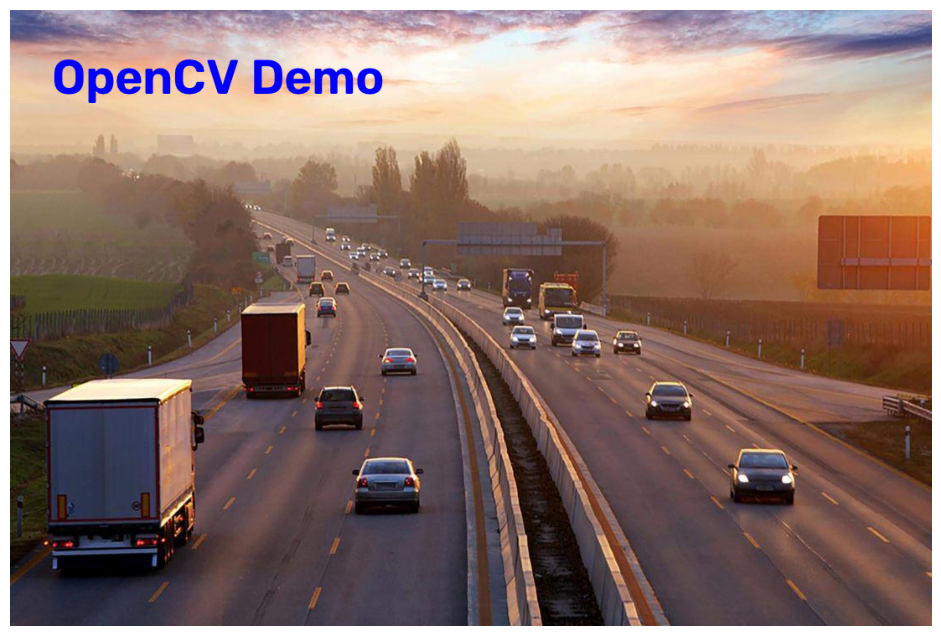

In [ ]:
import matplotlib.pyplot as plt

output = image.copy()

# Check image dimensions
print("Image shape:", image.shape)

# Add text
cv2.putText(
    output,
    'OpenCV Demo',
    (50, 100),                 # x, y
    cv2.FONT_HERSHEY_SIMPLEX,
    2,
    (255, 0, 0),
    4,
    cv2.LINE_AA
)

# Display
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis('off');